# Explore correlations for Arctic Ocean domain - ice free grid cells for all months

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import warnings
import s3fs
import gsw
import time

In [2]:
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [3]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:40453")
client

<Client: 'tcp://127.0.0.1:40453' processes=8 threads=32, memory=123.95 GiB>

### Open ocean mask

In [4]:
# open Arctic ocean mak
arctic_ocean_mask = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/Arctic_domain_mask/arctic_domain_mask.nc")

In [5]:
# select variable
ocean_mask = arctic_ocean_mask.arctic_ocean_mask

### Open geometry file

In [8]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [9]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

### First generate monthly mean datasets

In [5]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [6]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [7]:
# open SALT zarr store - [psu]
SALT_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open sea ice zarr store
SIarea_zarr = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

### Apply Arctic ocean domain mask

In [14]:
# isolate arctic ocean
salt_Arctic = SALT_zarr.SALT.where(HH_grid.mask_basin==1).where(ocean_mask)
theta_Arctic = THETA_zarr.THETA.where(HH_grid.mask_basin==1).where(ocean_mask)
ice_Arctic = SIarea_zarr.SIarea.where(HH_grid.mask_basin.isel(k=0)==1).where(ocean_mask.isel(k=0))

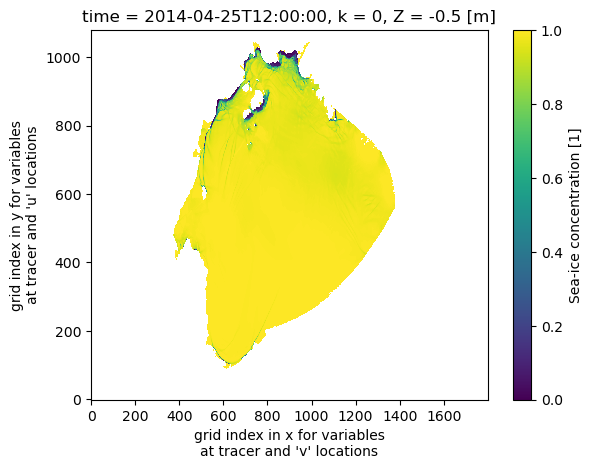

In [15]:
# double check
ice_Arctic.isel(time=100).plot();

### Calculate monthly means

In [26]:
# filter only 7 years of complete months (remove 2021) and then calculate monthly averages
salt_monthly = salt_Arctic.sel(time=slice("2014","2020")).resample(time="ME",label='left').mean()
theta_monthly = theta_Arctic.sel(time=slice("2014","2020")).resample(time="ME",label='left').mean()
ice_monthly = ice_Arctic.sel(time=slice("2014","2020")).resample(time="ME",label='left').mean()

In [28]:
# make label in the middle of the month
salt_monthly["time"] = salt_monthly.indexes["time"] + pd.DateOffset(days=15)
theta_monthly["time"] = theta_monthly.indexes["time"] + pd.DateOffset(days=15)
ice_monthly["time"] = ice_monthly.indexes["time"] + pd.DateOffset(days=15)

In [31]:
salt_monthly.time.values[0:12]

array(['2014-01-15T00:00:00.000000000', '2014-02-15T00:00:00.000000000',
       '2014-03-15T00:00:00.000000000', '2014-04-15T00:00:00.000000000',
       '2014-05-15T00:00:00.000000000', '2014-06-15T00:00:00.000000000',
       '2014-07-15T00:00:00.000000000', '2014-08-15T00:00:00.000000000',
       '2014-09-15T00:00:00.000000000', '2014-10-15T00:00:00.000000000',
       '2014-11-15T00:00:00.000000000', '2014-12-15T00:00:00.000000000'],
      dtype='datetime64[ns]')

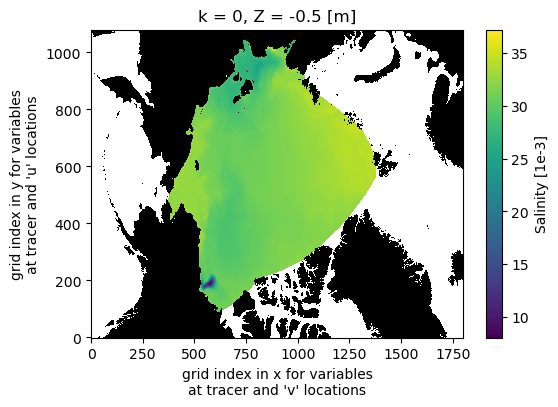

In [34]:
# take a look at surface salinity for one month
salt_monthly.isel(time=3,k=0).plot(figsize=[6,4]);
HH_grid_land.plot(vmin=-1,vmax=0,cmap='Grays',add_colorbar=False);

In [39]:
# Select only summer months of June, July, August, September
salt_JJAS = salt_monthly.sel(time=salt_monthly['time.month'].isin([6, 7, 8, 9]))
theta_JJAS = theta_monthly.sel(time=salt_monthly['time.month'].isin([6, 7, 8, 9]))
ice_JJAS = ice_monthly.sel(time=salt_monthly['time.month'].isin([6, 7, 8, 9]))

### Save datasets

In [40]:
salt_JJAS.to_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_JJAS_MONTHLY_MEAN_SALT.ZARR")
theta_JJAS.to_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_JJAS_MONTHLY_MEAN_THETA.ZARR")
ice_JJAS.to_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_JJAS_MONTHLY_MEAN_SIarea.ZARR")

### Calculate potential density

### Open monthly means

In [41]:
salt_JJAS = xr.open_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_JJAS_MONTHLY_MEAN_SALT.ZARR")
theta_JJAS = xr.open_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_JJAS_MONTHLY_MEAN_THETA.ZARR")

In [45]:
# select only vertical levels we want (surface, 20, and 100 m)
salt_levels = salt_JJAS.SALT.isel(k=[0,10,21])
theta_levels = theta_JJAS.THETA.isel(k=[0,10,21])

In [46]:
salt_levels.Z.values

array([ -0.5  , -21.125, -99.37 ], dtype=float32)

In [47]:
# pressure from depth
# Z needs to be positive up
pressure_da = gsw.p_from_z(HH_grid.isel(k=[0,10,21]).Z, HH_grid.YC).compute()

In [48]:
# just double check to make sure they look reasonable
pressure_da.isel(i=10,j=10).values

array([  0.50428623,  21.30716931, 100.246103  ])

In [49]:
# Calculates Absolute Salinity from Practical Salinity
salt_JJAS_levels = gsw.SA_from_SP(salt_levels, pressure_da, HH_grid.XC, HH_grid.YC)

In [50]:
# Calculates Conservative Temperature of seawater from potential temperature (whose reference sea pressure is zero dbar)
temp_JJAS_levels = gsw.CT_from_pt(salt_JJAS_levels, theta_levels)

In [51]:
# calculate potential density
sigma_JJAS_levels = gsw.density.sigma0(salt_JJAS_levels, temp_JJAS_levels)

# change name and clear salinity attrs
sigma_JJAS_levels.name = 'potential_density'
sigma_JJAS_levels.attrs = ""

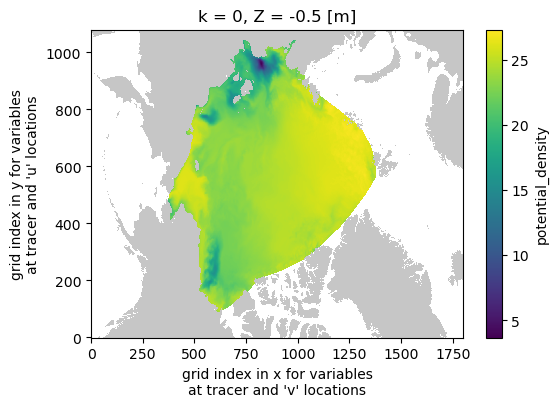

In [53]:
# take a look at density for sanity check
sigma_JJAS_levels.isel(time=3,k=0).plot(figsize=[6,4]);
HH_grid_land.plot(vmin=-1,vmax=2,cmap='Greys',add_colorbar=False);

### Save August potential density means for 0, 20, 100 m

In [55]:
sigma_JJAS_levels.to_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_JJAS_MONTHLY_MEAN_DENSITY.ZARR")

## Open summer monthly means

In [6]:
salt_JJAS = xr.open_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_JJAS_MONTHLY_MEAN_SALT.ZARR")
theta_JJAS = xr.open_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_JJAS_MONTHLY_MEAN_THETA.ZARR")
ice_JJAS = xr.open_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_JJAS_MONTHLY_MEAN_SIarea.ZARR")
sigma_JJAS = xr.open_zarr("~/efs-mount-point/mzahn/sassie/HH/ZARR/ARCTIC_OCEAN_JJAS_MONTHLY_MEAN_DENSITY.ZARR")

In [7]:
salt_JJAS = salt_JJAS.SALT
theta_JJAS = theta_JJAS.THETA 
ice_JJAS = ice_JJAS.SIarea
sigma_JJAS = sigma_JJAS.potential_density

## Make scatter plots for JJAS

In [8]:
# calculate potential density difference

# between surface and 20 m
delta_sigma_20m = sigma_JJAS.isel(k=0) - sigma_JJAS.isel(k=1)

# between surface and 100 m
delta_sigma_100m = sigma_JJAS.isel(k=0) - sigma_JJAS.isel(k=2)

### Scatter plots of $\Delta \sigma$ over upper 20m vs SSS and S(20m)

Delta rho in upper 20 m vs. SSS

#### First for just one year

In [37]:
theta_Jun.shape

(13608000,)

In [58]:
# select June, flatten array and remove nans ==========================================
# sigma_Jun_flat = delta_sigma_20m.sel(time=delta_sigma_20m['time.month']==6).values.flatten()
sigma_Jun_flat = delta_sigma_20m.sel(time='2018-06').values.flatten()
nan_mask = (~np.isnan(sigma_Jun_flat)) # using delta sigma mask since there are more nans resulting from this calculation
sigma_Jun = sigma_Jun_flat[nan_mask]

# salt_Jun_flat = salt_JJAS.isel(k=0).sel(time=salt_JJAS['time.month']==6).values.flatten()
salt_Jun_flat = salt_JJAS.isel(k=0).sel(time='2018-06').values.flatten()
salt_Jun = salt_Jun_flat[nan_mask]

# theta_Jun_flat = theta_JJAS.isel(k=0).sel(time=theta_JJAS['time.month']==6).values.flatten()
theta_Jun_flat = theta_JJAS.isel(k=0).sel(time='2018-06').values.flatten()
theta_Jun = theta_Jun_flat[nan_mask]

# select July, flatten array and remove nans ==========================================
# sigma_Jul_flat = delta_sigma_20m.sel(time=delta_sigma_20m['time.month']==7).values.flatten()
sigma_Jul_flat = delta_sigma_20m.sel(time='2018-07').values.flatten()
sigma_Jul = sigma_Jul_flat[nan_mask]

# salt_Jul_flat = salt_JJAS.isel(k=0).sel(time=salt_JJAS['time.month']==7).values.flatten()
salt_Jul_flat = salt_JJAS.isel(k=0).sel(time='2018-07').values.flatten()
salt_Jul = salt_Jul_flat[nan_mask]

# theta_Jul_flat = theta_JJAS.isel(k=0).sel(time=theta_JJAS['time.month']==7).values.flatten()
theta_Jul_flat = theta_JJAS.isel(k=0).sel(time='2018-07').values.flatten()
theta_Jul = theta_Jul_flat[nan_mask]

# select June, flatten array and remove nans ==========================================
# sigma_Aug_flat = delta_sigma_20m.sel(time=delta_sigma_20m['time.month']==8).values.flatten()
sigma_Aug_flat = delta_sigma_20m.sel(time='2018-08').values.flatten()
sigma_Aug = sigma_Aug_flat[nan_mask]

# salt_Aug_flat = salt_JJAS.isel(k=0).sel(time=salt_JJAS['time.month']==8).values.flatten()
salt_Aug_flat = salt_JJAS.isel(k=0).sel(time='2018-08').values.flatten()
salt_Aug = salt_Aug_flat[nan_mask]

# theta_Aug_flat = theta_JJAS.isel(k=0).sel(time=theta_JJAS['time.month']==8).values.flatten()
theta_Aug_flat = theta_JJAS.isel(k=0).sel(time='2018-08').values.flatten()
theta_Aug = theta_Aug_flat[nan_mask]

# select June, flatten array and remove nans ==========================================
# sigma_Sep_flat = delta_sigma_20m.sel(time=delta_sigma_20m['time.month']==9).values.flatten()
sigma_Sep_flat = delta_sigma_20m.sel(time='2018-09').values.flatten()
sigma_Sep = sigma_Sep_flat[nan_mask]

# salt_Sep_flat = salt_JJAS.isel(k=0).sel(time=salt_JJAS['time.month']==9).values.flatten()
salt_Sep_flat = salt_JJAS.isel(k=0).sel(time='2018-09').values.flatten()
salt_Sep = salt_Sep_flat[nan_mask]

# theta_Sep_flat = theta_JJAS.isel(k=0).sel(time=theta_JJAS['time.month']==9).values.flatten()
theta_Sep_flat = theta_JJAS.isel(k=0).sel(time='2018-09').values.flatten()
theta_Sep = theta_Sep_flat[nan_mask]

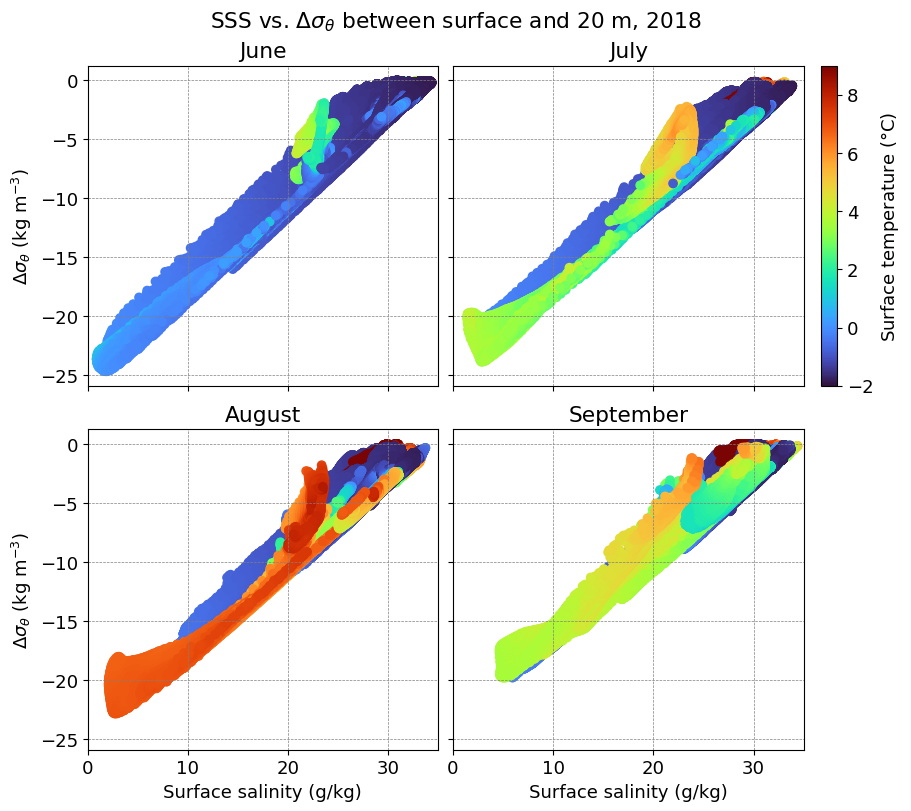

Time taken to plot: 0.5807 minutes


In [55]:
# Measure the time taken to plot
start_time = time.time()

plt.rcParams.update({'font.size': 13})

# plot max buoyancy freq by SSS, colored by SST
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=[9,8], sharey=True, sharex=True, layout='constrained')

# difference in density between surface and 20 m (surf-20)
ax1.scatter(salt_Jun, sigma_Jun, c=theta_Jun, cmap='turbo',vmin=-2,vmax=9);

cbar_temp = ax2.scatter(salt_Jul, sigma_Jul, c=theta_Jul, cmap='turbo',vmin=-2,vmax=9);

ax3.scatter(salt_Aug, sigma_Aug, c=theta_Aug, cmap='turbo',vmin=-2,vmax=9);

ax4.scatter(salt_Sep, sigma_Sep, c=theta_Sep, cmap='turbo',vmin=-2,vmax=9);

ax1.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
ax3.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax2)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

for ax in (ax1,ax2,ax3,ax4):
    ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
    ax.set_xlim(0,35)
    ax.set_xlabel("")

ax3.set_xlabel("Surface salinity (g/kg)")
ax4.set_xlabel("Surface salinity (g/kg)")

# titles
ax1.set_title("June")
ax2.set_title("July")
ax3.set_title("August")
ax4.set_title("September")

plt.suptitle(r'SSS vs. $\Delta \sigma_{\theta}$ between surface and 20 m, 2018');

plt.show()

end_time = time.time()  # End timer

# Compute and display elapsed time
elapsed_time = (end_time - start_time) / 60
print(f"Time taken to plot: {elapsed_time:.4f} minutes")

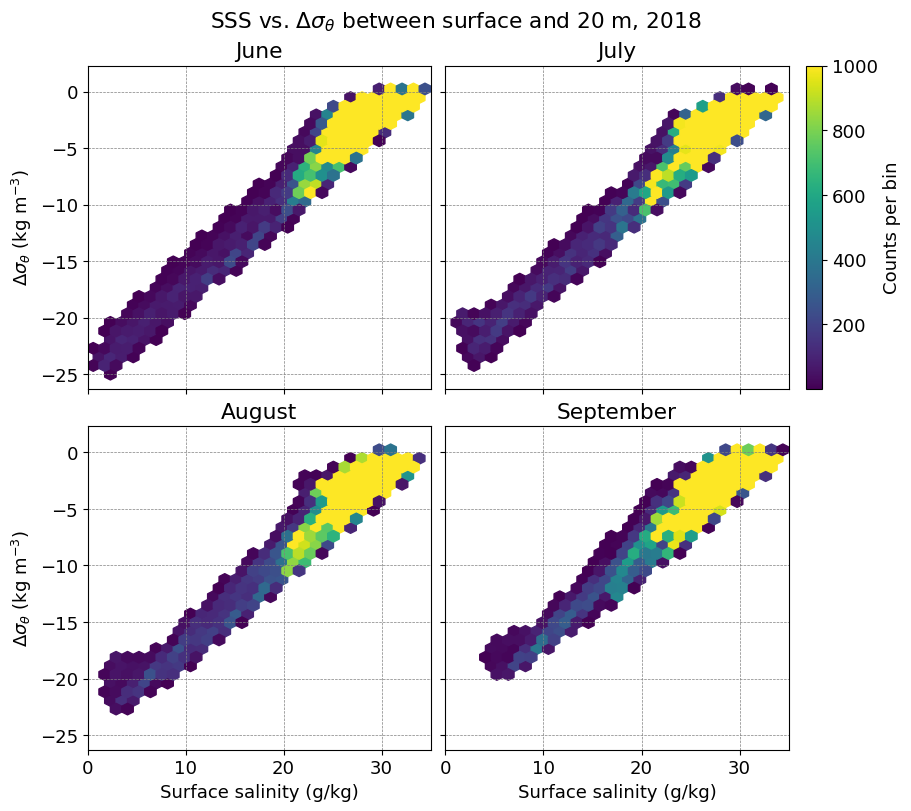

Time taken to plot: 0.0136 minutes


In [59]:
# Measure the time taken to plot
start_time = time.time()

plt.rcParams.update({'font.size': 13})

# plot max buoyancy freq by SSS, colored by SST
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=[9,8], sharey=True, sharex=True, layout='constrained')

# difference in density between surface and 20 m (surf-20)
extent = [0,35,-25,1]

ax1.hexbin(salt_Jun,sigma_Jun, gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
cbar_num = ax2.hexbin(salt_Jul,sigma_Jul, gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
ax3.hexbin(salt_Aug,sigma_Aug, gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)
ax4.hexbin(salt_Sep,sigma_Sep, gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=1000)

ax1.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
ax3.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_num,ax=ax2)
cbar.ax.set_ylabel('Counts per bin');

for ax in (ax1,ax2,ax3,ax4):
    ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
    ax.set_xlim(0,35)
    ax.set_xlabel("")

ax3.set_xlabel("Surface salinity (g/kg)")
ax4.set_xlabel("Surface salinity (g/kg)")

# titles
ax1.set_title("June")
ax2.set_title("July")
ax3.set_title("August")
ax4.set_title("September")

plt.suptitle(r'SSS vs. $\Delta \sigma_{\theta}$ between surface and 20 m, 2018');

plt.show()

end_time = time.time()  # End timer

# Compute and display elapsed time
elapsed_time = (end_time - start_time) / 60
print(f"Time taken to plot: {elapsed_time:.4f} minutes")

#### Now all 7 years

In [60]:
# select June, flatten array and remove nans ==========================================
sigma_Jun_flat = delta_sigma_20m.sel(time=delta_sigma_20m['time.month']==6).values.flatten()
nan_mask = (~np.isnan(sigma_Jun_flat)) # using delta sigma mask since there are more nans resulting from this calculation
sigma_Jun = sigma_Jun_flat[nan_mask]

salt_Jun_flat = salt_JJAS.isel(k=0).sel(time=salt_JJAS['time.month']==6).values.flatten()
salt_Jun = salt_Jun_flat[nan_mask]

theta_Jun_flat = theta_JJAS.isel(k=0).sel(time=theta_JJAS['time.month']==6).values.flatten()
theta_Jun = theta_Jun_flat[nan_mask]

# select July, flatten array and remove nans ==========================================
sigma_Jul_flat = delta_sigma_20m.sel(time=delta_sigma_20m['time.month']==7).values.flatten()
sigma_Jul = sigma_Jul_flat[nan_mask]

salt_Jul_flat = salt_JJAS.isel(k=0).sel(time=salt_JJAS['time.month']==7).values.flatten()
salt_Jul = salt_Jul_flat[nan_mask]

theta_Jul_flat = theta_JJAS.isel(k=0).sel(time=theta_JJAS['time.month']==7).values.flatten()
theta_Jul = theta_Jul_flat[nan_mask]

# select June, flatten array and remove nans ==========================================
sigma_Aug_flat = delta_sigma_20m.sel(time=delta_sigma_20m['time.month']==8).values.flatten()
sigma_Aug = sigma_Aug_flat[nan_mask]

salt_Aug_flat = salt_JJAS.isel(k=0).sel(time=salt_JJAS['time.month']==8).values.flatten()
salt_Aug = salt_Aug_flat[nan_mask]

theta_Aug_flat = theta_JJAS.isel(k=0).sel(time=theta_JJAS['time.month']==8).values.flatten()
theta_Aug = theta_Aug_flat[nan_mask]

# select June, flatten array and remove nans ==========================================
sigma_Sep_flat = delta_sigma_20m.sel(time=delta_sigma_20m['time.month']==9).values.flatten()
sigma_Sep = sigma_Sep_flat[nan_mask]

salt_Sep_flat = salt_JJAS.isel(k=0).sel(time=salt_JJAS['time.month']==9).values.flatten()
salt_Sep = salt_Sep_flat[nan_mask]

theta_Sep_flat = theta_JJAS.isel(k=0).sel(time=theta_JJAS['time.month']==9).values.flatten()
theta_Sep = theta_Sep_flat[nan_mask]

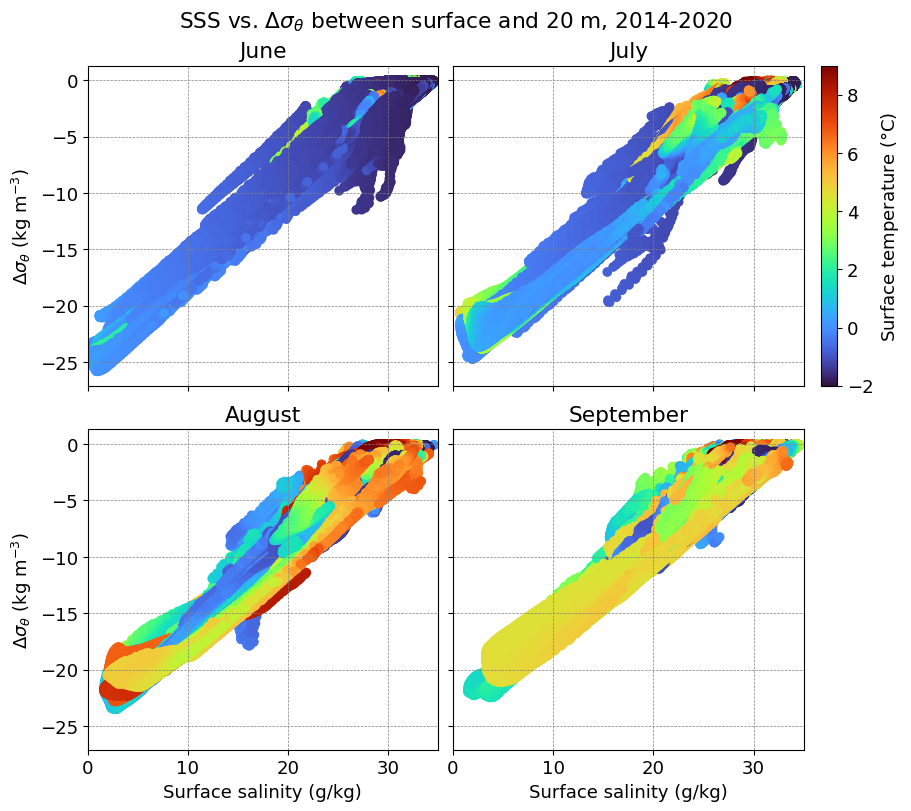

Time taken to plot: 4.0521 minutes


In [57]:
# Measure the time taken to plot
start_time = time.time()

plt.rcParams.update({'font.size': 13})

# plot max buoyancy freq by SSS, colored by SST
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=[9,8], sharey=True, sharex=True, layout='constrained')

# difference in density between surface and 20 m (surf-20)
ax1.scatter(salt_Jun, sigma_Jun, c=theta_Jun, cmap='turbo',vmin=-2,vmax=9);

cbar_temp = ax2.scatter(salt_Jul, sigma_Jul, c=theta_Jul, cmap='turbo',vmin=-2,vmax=9);

ax3.scatter(salt_Aug, sigma_Aug, c=theta_Aug, cmap='turbo',vmin=-2,vmax=9);

ax4.scatter(salt_Sep, sigma_Sep, c=theta_Sep, cmap='turbo',vmin=-2,vmax=9);

ax1.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
ax3.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_temp,ax=ax2)
cbar.ax.set_ylabel('Surface temperature ($\degree$C)');

for ax in (ax1,ax2,ax3,ax4):
    ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
    ax.set_xlim(0,35)
    ax.set_xlabel("")

ax3.set_xlabel("Surface salinity (g/kg)")
ax4.set_xlabel("Surface salinity (g/kg)")

# titles
ax1.set_title("June")
ax2.set_title("July")
ax3.set_title("August")
ax4.set_title("September")

plt.suptitle(r'SSS vs. $\Delta \sigma_{\theta}$ between surface and 20 m, 2014-2020');

plt.show()

end_time = time.time()  # End timer

# Compute and display elapsed time
elapsed_time = (end_time - start_time) / 60
print(f"Time taken to plot: {elapsed_time:.4f} minutes")

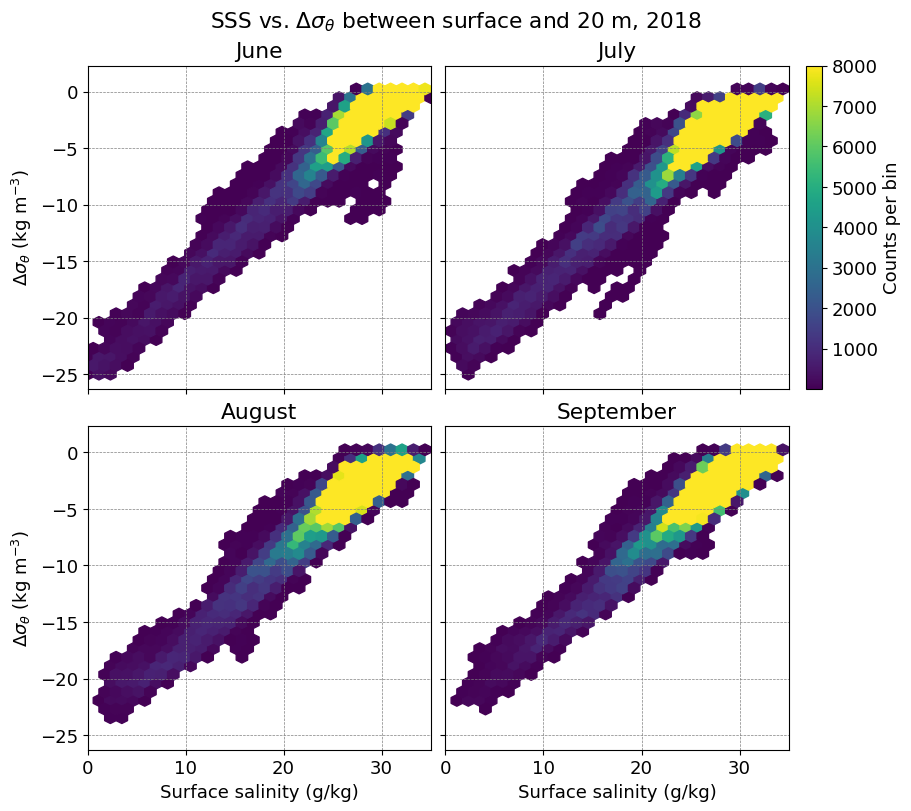

Time taken to plot: 0.0296 minutes


In [62]:
# Measure the time taken to plot
start_time = time.time()

plt.rcParams.update({'font.size': 13})

# plot max buoyancy freq by SSS, colored by SST
fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=[9,8], sharey=True, sharex=True, layout='constrained')

# difference in density between surface and 20 m (surf-20)
extent = [0,35,-25,1]

ax1.hexbin(salt_Jun,sigma_Jun, gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=8000)
cbar_num = ax2.hexbin(salt_Jul,sigma_Jul, gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=8000)
ax3.hexbin(salt_Aug,sigma_Aug, gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=8000)
ax4.hexbin(salt_Sep,sigma_Sep, gridsize=30, cmap='viridis', mincnt=1, extent=extent, vmin=1, vmax=8000)

ax1.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')
ax3.set_ylabel(r'$\Delta \sigma_{\theta}$ (kg m$^{-3}$)')

# Make a colorbar for the ContourSet returned by the contourf call.
cbar = fig.colorbar(cbar_num,ax=ax2)
cbar.ax.set_ylabel('Counts per bin');

for ax in (ax1,ax2,ax3,ax4):
    ax.grid(linestyle='dashed',color='gray',linewidth=0.5)
    ax.set_xlim(0,35)
    ax.set_xlabel("")

ax3.set_xlabel("Surface salinity (g/kg)")
ax4.set_xlabel("Surface salinity (g/kg)")

# titles
ax1.set_title("June")
ax2.set_title("July")
ax3.set_title("August")
ax4.set_title("September")

plt.suptitle(r'SSS vs. $\Delta \sigma_{\theta}$ between surface and 20 m, 2018');

plt.show()

end_time = time.time()  # End timer

# Compute and display elapsed time
elapsed_time = (end_time - start_time) / 60
print(f"Time taken to plot: {elapsed_time:.4f} minutes")